In [1]:
from scipy.io import wavfile
import numpy as np
from ml_tools.utilities import rolling_windows_nd, standardize_data
from ml_tools.models.layers.operators import LatentStack
from ml_tools.models.model_loss import MSELoss
from ml_tools.models.optimizers import SGD
from ml_tools.models.layers.layers import (
    FrequencyFFT,
    FullyConnectedLayer,
    DropoutLayer,
    NormalizeLayer,
)
from ml_tools.models.blocks import (
    FourierAttention,
    SpectreAttention)
from ml_tools.models.embedding.positional import RopeEmbedding
from ml_tools.models.neural_network import NeuralNetwork
import matplotlib.pyplot as plt

MAX_POSSIBLE_WINDOWS = 5000


/var/folders/v1/q6fjybyj75s5vl9h5zylkbnw0000gp/T/ipykernel_75133/483495320.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, waveform = wavfile.read(


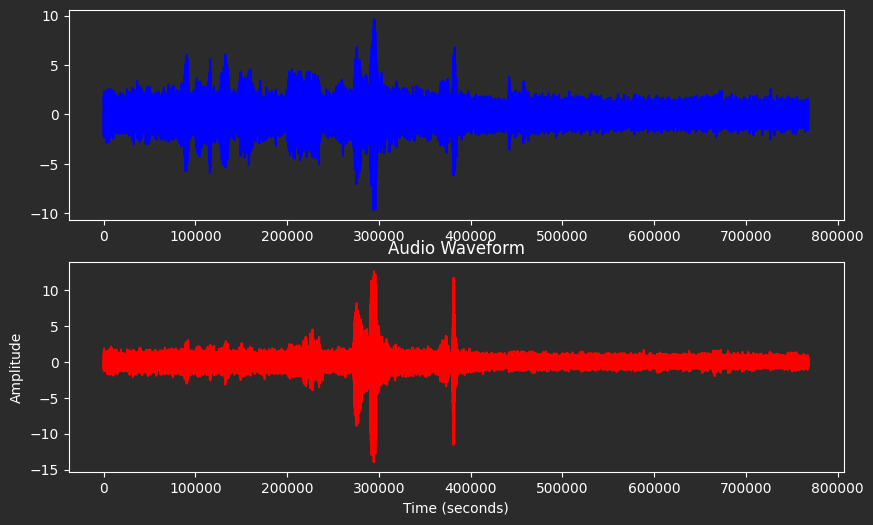

In [2]:
sample_rate, waveform = wavfile.read(
    "../test.wav"
)

waveform_l, waveform_r = (
    standardize_data(waveform[:, 0]),
    standardize_data(waveform[:, 1]),
)
num_samples = waveform.shape[0]

xs = np.arange(0, num_samples)
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(xs, waveform_l, color="blue")
plt.subplot(2, 1, 2)
plt.plot(xs, waveform_r, color="red")
plt.title("Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


In [3]:
from ml_tools.models.neural_network import Node, NeuralNetwork

net = NeuralNetwork(name="spectral_fnet", input_shape=(10,))

in_layer = net.input
# this is not the most straightforward wiring; but I'm not coming up with a plainer DAG process that's flexible...
fc_a = net.connect(FullyConnectedLayer(10, 12, "relu"), in_layer, name="branch_a_fc")
fc_norm = net.connect(NormalizeLayer(12, shift_scale=True), fc_a, name="branch_a_norm")

# demo of a split connection
fc_b = net.connect(FullyConnectedLayer(10, 4, "tanh"), in_layer, name="branch_b_fc")

# stacking the two branches back --
merged = net.connect(LatentStack(), fc_norm, fc_b, name="merge_branches")
drop = net.connect(DropoutLayer(dropout_prob=0.1), merged, name="merge_dropout")
fc_c = net.connect(FullyConnectedLayer(16, 8, "swish"), drop, name="merge_fc")
net.output = net.connect(FullyConnectedLayer(8, 1, "linear", is_output=True), fc_c, name="output")

In [4]:
net

NeuralNetwork(7 nodes, 345 parameters)

In [5]:
print(net.summary())

spectral_fnet: 7 nodes, 345 parameters
  node            sources                    shape
  branch_a_fc     input                      (12,)
  branch_a_norm   branch_a_fc                (12,)
  branch_b_fc     input                      (4,)
  merge_branches  branch_a_norm,branch_b_fc  (16,)
  merge_dropout   merge_branches             (16,)
  merge_fc        merge_dropout              (8,)
  output          merge_fc                   (1,) <- output


In [7]:
net.get_node("branch_a_fc")

Node(branch_a_fc <- input)